<a href="https://colab.research.google.com/github/milica-tomic/Cooperative_game/blob/main/Cooperative_game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn import datasets
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import  LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
class DataPreprocessing:
  def __init__(self, filename):
    self.df = pd.read_csv(filename)

  def head(self):
    return self.df.head()

  def info(self):
    return self.df.info()

  def clean_data(self, drop_columns):
    self.df = self.df.drop(columns = drop_columns)

  def fill_missing_data(self, fill_map):
    for col, method in fill_map.items():
      if method == 'mean':
        self.df[col] = self.df[col].fillna(self.df[col].mean())
      elif method == 'median':
        self.df[col] = self.df[col].fillna(self.df[col].median())

  def split_standardize_data(self, test_size, random_state = 10):
    x = self.df.iloc[:, 1:]
    y = self.df.iloc[:, 0]
    xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=test_size, random_state=random_state, stratify=y)
    s = StandardScaler()
    s.fit(xtrain)
    x_train_std = s.transform(xtrain)
    x_test_std = s.transform(xtest)
    x_train_std = pd.DataFrame(x_train_std)
    x_test_std = pd.DataFrame(x_test_std)
    x_train_std.columns = list(x.columns)
    x_test_std.columns = list(x.columns)


    return x_train_std, x_test_std, ytrain, ytest




In [ ]:
class MLModels:
    def __init__(self, model, param):
        self.model = model
        self.param = param
        self.best_score = None
        self.best_params = None
        self.y_pred = None
        self.y_test = None

    def GridSearchCV(self, xtrain_std, xtest_std, ytrain, ytest):
        self.y_test = ytest

        if isinstance(self.model, SVC):
            self.best_score = 0
            self.best_params = None

            # Ručna pretraga hiperparametra C
            for C in self.param:
                classifier = SVC(C=C, kernel='linear')
                classifier.fit(xtrain_std, ytrain)
                y_pred_loop = classifier.predict(xtest_std)
                recall = metrics.recall_score(ytest, y_pred_loop)
                if recall > self.best_score:
                    self.best_score = recall
                    self.best_params = C

            print("najbolji skor: ", self.best_score)
            print("najbolji hiperparametar C: ", self.best_params)

            # Finalni model sa najboljim C
            classifier_final = SVC(C=self.best_params, kernel='rbf', gamma='scale')
            classifier_final.fit(xtrain_std, ytrain)
            self.y_pred = classifier_final.predict(xtest_std)

        else:
            clf = GridSearchCV(self.model, self.param, scoring='recall', cv=10)
            clf.fit(xtrain_std, ytrain)
            self.best_score = clf.best_score_
            self.best_params = clf.best_params_
            print("najbolji skor: ", self.best_score)
            print("najbolji hiperparametri: ", self.best_params)
            self.y_pred = clf.predict(xtest_std)

        return self.y_pred, self.best_score, self.best_params

    def score(self):
        if self.y_pred is None or self.y_test is None:
            raise ValueError("Prvo pokrenuti fuknciju GridSearchCV")
        precision = metrics.precision_score(self.y_test, self.y_pred)
        accuracy = metrics.accuracy_score(self.y_test, self.y_pred)
        sensitivity = metrics.recall_score(self.y_test, self.y_pred)
        f_score = metrics.f1_score(self.y_test, self.y_pred)
        return precision, accuracy, sensitivity, f_score

    def print_metrics(self):
        precision, accuracy, sensitivity, f_score = self.score()
        print(f'Precision: {precision:.4f}')
        print(f'Accuracy: {accuracy:.4f}')
        print(f'Sensitivity/Recall: {sensitivity:.4f}')
        print(f'F score: {f_score:.4f}')

    def plot_confusion_matrix(self):
      cm = metrics.confusion_matrix(self.y_test, self.y_pred)
      plt.figure(figsize=(6, 5))
      sns.heatmap(
          cm,
          annot=True,
          fmt='g',
          cmap="Blues",
          cbar=False,
          linewidths=0.5,
          linecolor='black',
          xticklabels=['Predviđeno 0', 'Predviđeno 1'],
          yticklabels=['Stvarno 0', 'Stvarno 1']
      )
      plt.title("Matrica Konfuzije")
      plt.xlabel("Predviđena klasa")
      plt.ylabel("Stvarna klasa")
      plt.show()


In [ ]:
class FusionModel():
  def __init__(self, y_pred_knn, y_pred_svm, y_pred_dt, sensitivity_knn, sensitivity_svm, sensitivity_dt, ytest):
    self.y_pred_knn = y_pred_knn
    self.y_pred_svm = y_pred_svm
    self.y_pred_dt =  y_pred_dt

    self.predictions = np.array([self.y_pred_knn, self.y_pred_svm, self.y_pred_dt])

    self.sensitivity_knn = sensitivity_knn
    self.sensitivity_svm = sensitivity_svm
    self.sensitivity_dt = sensitivity_dt

    self.recalls = np.array([ self.sensitivity_knn,  self.sensitivity_svm,  self.sensitivity_dt])

    self.ytest = ytest

    self.weights = self.recalls / np.sum(self.recalls)

    self.fusion = np.round(np.average(self.predictions, axis=0, weights=self.weights))

    self.models_recall  = {"kNN" : self.sensitivity_knn,
                           "svm" : self.sensitivity_svm,
                           "decision_tree" : self.sensitivity_dt}

  def get_metrics(self):
      precision = metrics.precision_score(self.ytest, self.fusion)
      accuracy = metrics.accuracy_score(self.ytest, self.fusion)
      sensitivity = metrics.recall_score(self.ytest, self.fusion)
      f_score = metrics.f1_score(self.ytest, self.fusion)
      return precision, accuracy, sensitivity, f_score

  def print_metrics(self):
      precision, accuracy, sensitivity, f_score = self.get_metrics()
      print('\n--- REZULTATI KOOPERATIVNOG SISTEMA ---')
      print(f'Precision: {precision:.4f}')
      print(f'Accuracy: {accuracy:.4f}')
      print(f'Sensitivity/Recall: {sensitivity:.4f}')
      print(f'F score: {f_score:.4f}')

  def plot_recalls_bar(self):

    recalls = self.models_recall

    fusion_recall = metrics.recall_score(self.ytest, self.fusion)
    labels = list(recalls.keys()) + ["Fuzija (Ensemble)"]
    accuracies = list(recalls.values()) + [fusion_recall]
    colors = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"]

    plt.figure(figsize=(9, 5))
    bars = plt.bar(labels, accuracies, color=colors)
    plt.ylabel("Recall (Osetljivost)")
    plt.title("Poređenje Recall performansi pojedinačnih i kooperativnog sistema")
    plt.ylim(0, 1.0)
    # Dodajemo vrednosti iznad stubova
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


  def plot_confusion_matrix(self):
    cm = metrics.confusion_matrix(self.ytest, self.fusion)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='g',
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor='black',
        xticklabels=['Predviđeno 0', 'Predviđeno 1'],
        yticklabels=['Stvarno 0', 'Stvarno 1']
    )
    plt.title("Matrica Konfuzije")
    plt.xlabel("Predviđena klasa")
    plt.ylabel("Stvarna klasa")
    plt.show()





# Importing data and Data Preprocessing

In [ ]:
dataset_path = 'data.csv'

dp = DataPreprocessing(dataset_path)

print(dp.head())
dp.info()


columns_to_delete = ['Pregnancy', 'Patient_Number']
columns_to_fill = {'Genetic_Pedigree_Coefficient': 'mean', 'alcohol_consumption_per_day': 'median'}

dp.clean_data(columns_to_delete)
dp.fill_missing_data(columns_to_fill)

dp.info()

xtrain_std, xtest_std, ytrain, ytest = dp.split_standardize_data(0.1, random_state = 10)


   Patient_Number  Blood_Pressure_Abnormality  Level_of_Hemoglobin  \
0               1                           1                11.28   
1               2                           0                 9.75   
2               3                           1                10.79   
3               4                           0                11.00   
4               5                           1                14.17   

   Genetic_Pedigree_Coefficient  Age  BMI  Sex  Pregnancy  Smoking  \
0                          0.90   34   23    1        1.0        0   
1                          0.23   54   33    1        NaN        0   
2                          0.91   70   49    0        NaN        0   
3                          0.43   71   50    0        NaN        0   
4                          0.83   52   19    0        NaN        0   

   Physical_activity  salt_content_in_the_diet  alcohol_consumption_per_day  \
0              45961                     48071                          NaN   


#kNN

najbolji skor:  0.7039836567926455
najbolji hiperparametri:  {'metric': 'manhattan', 'n_neighbors': 7}
Precision: 0.8795
Accuracy: 0.8200
Sensitivity/Recall: 0.7374
F score: 0.8022


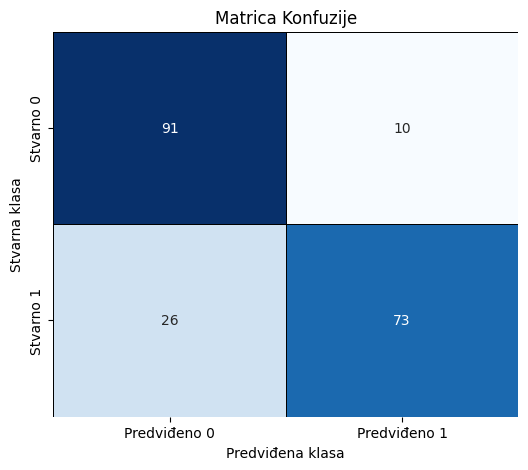

In [ ]:
knn = KNeighborsClassifier()
param = {'n_neighbors':[1,2,3,4,5,6,7,8,9,10], 'metric':('hamming', 'euclidean', 'manhattan','chebyshev')}

model_knn = MLModels(knn, param)

model_knn.GridSearchCV(xtrain_std, xtest_std, ytrain, ytest)

model_knn.print_metrics()

model_knn.plot_confusion_matrix()

# SVM

najbolji skor:  0.6868686868686869
najbolji hiperparametar C:  0.1
Precision: 0.7364
Accuracy: 0.7650
Sensitivity/Recall: 0.8182
F score: 0.7751


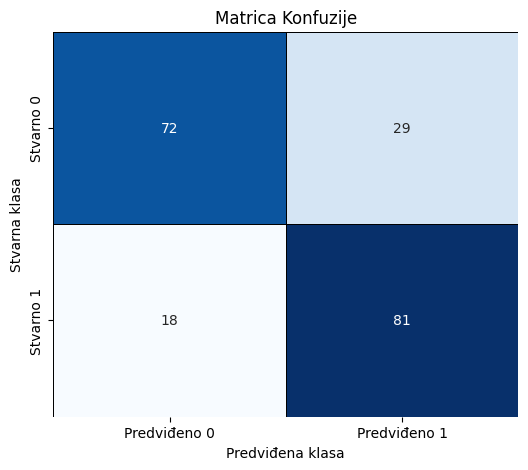

In [ ]:
svm = SVC()
param = [0.1, 0.2, 0.5, 1, 2, 5, 10]

model_svm = MLModels(svm, param)

model_svm.GridSearchCV(xtrain_std, xtest_std, ytrain, ytest)

model_svm.print_metrics()

model_svm.plot_confusion_matrix()

# DECISION TREE

najbolji skor:  0.8829162410623084
najbolji hiperparametri:  {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 30}
Precision: 0.9072
Accuracy: 0.9000
Sensitivity/Recall: 0.8889
F score: 0.8980


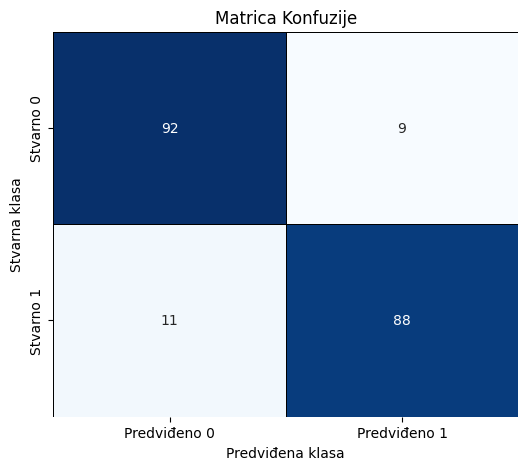

In [ ]:
decision_tree = DecisionTreeClassifier()

param = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [5, 10, 15, 20, 25, 30, 35]
}

model_dt = MLModels(decision_tree, param)

model_dt.GridSearchCV(xtrain_std, xtest_std, ytrain, ytest)

model_dt.print_metrics()

model_dt.plot_confusion_matrix()

# FUSION MODEL


--- REZULTATI KOOPERATIVNOG SISTEMA ---
Precision: 0.8842
Accuracy: 0.8700
Sensitivity/Recall: 0.8485
F score: 0.8660


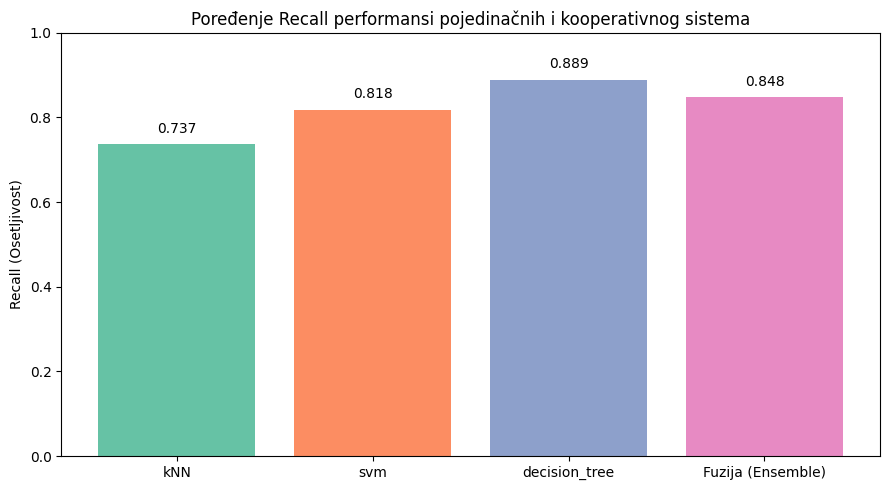

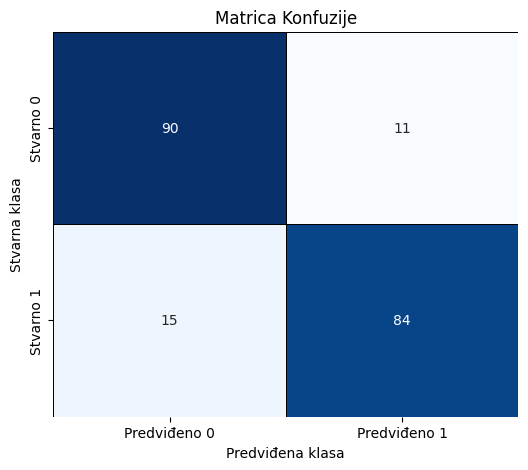

In [ ]:
y_pred_knn = model_knn.y_pred
_, _, sensitivity_knn, _ = model_knn.score()
y_pred_svm = model_svm.y_pred
_, _, sensitivity_svm, _ = model_svm.score()
y_pred_dt = model_dt.y_pred
_, _, sensitivity_dt, _ = model_dt.score()

fusion = FusionModel(y_pred_knn, y_pred_svm, y_pred_dt, sensitivity_knn, sensitivity_svm, sensitivity_dt, ytest)

fusion.get_metrics()
fusion.print_metrics()
fusion.plot_recalls_bar()
fusion.plot_confusion_matrix()
